<a href="https://colab.research.google.com/github/rezkanorhafizah/ME-XBal/blob/main/single_label_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#ME-XBAL (Multilingual Emotion eXplainable BALancer)

In [3]:
# ==========================================
# 🔬 SINGLE-LABEL EXPERIMENT (INDO-SUNDA)
# ==========================================
import pandas as pd
import numpy as np
import torch
import joblib
import xgboost as xgb
from sklearn.metrics import f1_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from transformers import AutoTokenizer, AutoModel
from tqdm import tqdm

# ================================
# LOAD DATA
# ================================
train_path = "/content/drive/MyDrive/INASS Project/dataset/IndoSunda/data_train.csv"
test_path  = "/content/drive/MyDrive/INASS Project/dataset/IndoSunda/data_test.csv"

df_train = pd.read_csv(train_path)
df_test  = pd.read_csv(test_path)

print(f"Train: {len(df_train)}, Test: {len(df_test)}")

# ================================
# DETECT LABEL COLUMN (ADJUST IF NEEDED)
# ================================
print("\nColumns:", df_train.columns)

# GANTI kalau nama kolom label beda
label_col = "Label_Emosi"
text_col  = "Teks_Komentar"

# ================================
# ENCODE LABEL
# ================================
le = LabelEncoder()
y_train = le.fit_transform(df_train[label_col])
y_test  = le.transform(df_test[label_col])

num_classes = len(le.classes_)
print("Classes:", le.classes_)

# ================================
# LOAD XLM-R
# ================================
MODEL_NAME = "xlm-roberta-base"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModel.from_pretrained(MODEL_NAME)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device).eval()

# ================================
# EMBEDDING FUNCTION
# ================================
def extract_embeddings(texts, batch_size=32):
    embeddings = []
    for i in tqdm(range(0, len(texts), batch_size)):
        batch = texts[i:i+batch_size]

        inputs = tokenizer(
            batch,
            padding=True,
            truncation=True,
            max_length=128,
            return_tensors="pt"
        ).to(device)

        with torch.no_grad():
            outputs = model(**inputs)
            cls = outputs.last_hidden_state[:, 0, :].cpu().numpy()
            embeddings.append(cls)

    return np.vstack(embeddings)

# ================================
# EXTRACT FEATURES
# ================================
print("\n🔄 Extracting embeddings...")
X_train = extract_embeddings(df_train[text_col].astype(str).tolist())
X_test  = extract_embeddings(df_test[text_col].astype(str).tolist())

# ================================
# LOAD PREPROCESSING (PAKAI MODEL KAMU!)
# ================================
scaler = joblib.load("/content/drive/MyDrive/INASS Project/results/scaler_multilingual.pkl")
pca    = joblib.load("/content/drive/MyDrive/INASS Project/results/pca_multilingual.pkl")

X_train = pca.transform(scaler.transform(X_train))
X_test  = pca.transform(scaler.transform(X_test))

# ================================
# TRAIN MODELS
# ================================
print("\n🏋️ Training models...")

# XGBoost (multi-class)
xgb_model = xgb.XGBClassifier(
    objective='multi:softprob',
    num_class=num_classes,
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    random_state=42
)
xgb_model.fit(X_train, y_train)

# Logistic Regression
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)

# ================================
# PREDICTION (HYBRID)
# ================================
print("\n🔍 Predicting...")

xgb_proba = xgb_model.predict_proba(X_test)
lr_proba  = lr_model.predict_proba(X_test)

# Hybrid (ME-XBAL style)
hybrid_proba = 0.7 * xgb_proba + 0.3 * lr_proba

y_pred = np.argmax(hybrid_proba, axis=1)

# ================================
# EVALUATION
# ================================
macro_f1 = f1_score(y_test, y_pred, average='macro')
micro_f1 = f1_score(y_test, y_pred, average='micro')

print("\n📊 RESULTS (INDO-SUNDA SINGLE-LABEL)")
print("="*50)
print(f"Macro F1 : {macro_f1:.4f}")
print(f"Micro F1 : {micro_f1:.4f}")

print("\n📋 Classification Report:")
labels = np.arange(len(le.classes_))

print(classification_report(
    y_test,
    y_pred,
    labels=labels,
    target_names=le.classes_,
    zero_division=0
))

Train: 3111, Test: 777

Columns: Index(['Label_Emosi', 'Teks_Komentar'], dtype='object')
Classes: ['Anger' 'Disgust' 'Fear' 'Neutral' 'Sadness']


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



🔄 Extracting embeddings...


100%|██████████| 25/25 [00:01<00:00, 14.26it/s]



🏋️ Training models...

🔍 Predicting...

📊 RESULTS (INDO-SUNDA SINGLE-LABEL)
Macro F1 : 0.5338
Micro F1 : 0.8082

📋 Classification Report:
              precision    recall  f1-score   support

       Anger       0.81      0.45      0.58       114
     Disgust       0.82      0.97      0.89       566
        Fear       0.00      0.00      0.00         0
     Neutral       0.72      0.29      0.41        80
     Sadness       0.50      0.18      0.26        17

    accuracy                           0.81       777
   macro avg       0.57      0.38      0.43       777
weighted avg       0.80      0.81      0.78       777



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [6]:
# ==========================================
# 🔬 ABLATION STUDY - SINGLE LABEL (INDO-SUNDA)
# ==========================================
import numpy as np
import pandas as pd
import torch
import joblib
import xgboost as xgb
from transformers import AutoTokenizer, AutoModel
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score
from sklearn.preprocessing import LabelEncoder
from tqdm import tqdm

# ================================
# LOAD DATA
# ================================
train_path = "/content/drive/MyDrive/INASS Project/dataset/IndoSunda/data_train.csv"
test_path  = "/content/drive/MyDrive/INASS Project/dataset/IndoSunda/data_test.csv"

df_train = pd.read_csv(train_path)
df_test  = pd.read_csv(test_path)

label_col = "Label_Emosi"
text_col  = "Teks_Komentar"

# ================================
# LABEL ENCODING
# ================================
le = LabelEncoder()
y_train = le.fit_transform(df_train[label_col])
y_test  = le.transform(df_test[label_col])
num_classes = len(le.classes_)

# ================================
# LOAD PREPROCESSING
# ================================
scaler = joblib.load("/content/drive/MyDrive/INASS Project/results/scaler_multilingual.pkl")
pca    = joblib.load("/content/drive/MyDrive/INASS Project/results/pca_multilingual.pkl")

# ================================
# LOAD TRANSFORMERS
# ================================
def load_model(name):
    tok = AutoTokenizer.from_pretrained(name)
    mod = AutoModel.from_pretrained(name)
    return tok, mod

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

xlmr_tok, xlmr_mod = load_model("xlm-roberta-base")
indo_tok, indo_mod = load_model("indobenchmark/indobert-base-p1")

xlmr_mod.to(device).eval()
indo_mod.to(device).eval()

# ================================
# EMBEDDING FUNCTION
# ================================
def extract(texts, tokenizer, model):
    out = []
    for i in tqdm(range(0, len(texts), 32)):
        batch = texts[i:i+32]
        inputs = tokenizer(
            batch,
            padding=True,
            truncation=True,
            max_length=128,
            return_tensors="pt"
        ).to(device)

        with torch.no_grad():
            outputs = model(**inputs)
            cls = outputs.last_hidden_state[:, 0, :].cpu().numpy()
            out.append(cls)

    return np.vstack(out)

# ================================
# EXTRACT FEATURES
# ================================
texts_train = df_train[text_col].astype(str).tolist()
texts_test  = df_test[text_col].astype(str).tolist()

print("🔄 Extracting XLM-R embeddings...")
X_xlmr_train = pca.transform(scaler.transform(extract(texts_train, xlmr_tok, xlmr_mod)))
X_xlmr_test  = pca.transform(scaler.transform(extract(texts_test, xlmr_tok, xlmr_mod)))

print("🔄 Extracting IndoBERT embeddings...")
X_indo_train = pca.transform(scaler.transform(extract(texts_train, indo_tok, indo_mod)))
X_indo_test  = pca.transform(scaler.transform(extract(texts_test, indo_tok, indo_mod)))

# ================================
# TRAIN FUNCTIONS
# ================================
def train_xgb(X, y):
    model = xgb.XGBClassifier(
        objective='multi:softprob',
        num_class=num_classes,
        n_estimators=200,
        max_depth=4,
        learning_rate=0.05,
        random_state=42
    )
    model.fit(X, y)
    return model

def train_lr(X, y):
    model = LogisticRegression(max_iter=1000)
    model.fit(X, y)
    return model

# ================================
# PREDICT FUNCTION
# ================================
def predict(model_xgb=None, model_lr=None, X=None, ensemble=False):
    if ensemble:
        proba = 0
        if model_xgb:
            proba += model_xgb.predict_proba(X)
        if model_lr:
            proba += model_lr.predict_proba(X)
        proba /= (int(model_xgb is not None) + int(model_lr is not None))
    else:
        if model_xgb:
            proba = model_xgb.predict_proba(X)
        else:
            proba = model_lr.predict_proba(X)

    return np.argmax(proba, axis=1)

# ================================
# TRAIN ALL MODELS
# ================================
models = {}

# XLM-R
models["XLM-R LR"] = (None, train_lr(X_xlmr_train, y_train))
models["XLM-R XGB"] = (train_xgb(X_xlmr_train, y_train), None)
models["XLM-R Hybrid"] = (
    train_xgb(X_xlmr_train, y_train),
    train_lr(X_xlmr_train, y_train)
)

# IndoBERT
models["IndoBERT LR"] = (None, train_lr(X_indo_train, y_train))
models["IndoBERT XGB"] = (train_xgb(X_indo_train, y_train), None)
models["IndoBERT Hybrid"] = (
    train_xgb(X_indo_train, y_train),
    train_lr(X_indo_train, y_train)
)

# ================================
# EVALUATION
# ================================
print("\n📊 RESULTS (INDO-SUNDA SINGLE-LABEL - MACRO F1)")
print("="*60)

results_dict = {}

for name, (xgb_m, lr_m) in models.items():
    X_test_used = X_xlmr_test if "XLM-R" in name else X_indo_test

    y_pred = predict(
        xgb_m,
        lr_m,
        X_test_used,
        ensemble=(xgb_m is not None and lr_m is not None)
    )

    # Macro F1 (valid classes only)
    f1 = f1_score(y_test, y_pred, labels=np.unique(y_test), average='macro')

    results_dict[name] = f1

# PRINT NICE FORMAT
for name, score in results_dict.items():
    print(f"\n🔹 {name}")
    print(f"  Macro F1 : {score:.4f}")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

🔄 Extracting XLM-R embeddings...


100%|██████████| 25/25 [00:01<00:00, 13.71it/s]


🔄 Extracting IndoBERT embeddings...


100%|██████████| 25/25 [00:01<00:00, 15.11it/s]
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linea


📊 RESULTS (INDO-SUNDA SINGLE-LABEL - MACRO F1)

🔹 XLM-R LR
  Macro F1 : 0.4360

🔹 XLM-R XGB
  Macro F1 : 0.5415

🔹 XLM-R Hybrid
  Macro F1 : 0.5125

🔹 IndoBERT LR
  Macro F1 : 0.3923

🔹 IndoBERT XGB
  Macro F1 : 0.4040

🔹 IndoBERT Hybrid
  Macro F1 : 0.3959


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# ================================
# DATA
# ================================
models = [
    "ME-XBAL",
    "XLM-R Hybrid",
    "XLM-R LR",
    "XLM-R XGB",
    "IndoBERT LR",
    "IndoBERT XGB",
    "IndoBERT Hybrid"
]

sunda = [0.4755, 0.3386, 0.4156, 0.2488, 0.1930, 0.1404, 0.1674]
javanese = [0.4548, 0.2214, 0.3250, 0.1281, 0.1389, 0.0894, 0.1345]
indonesian = [0.4978, 0.2636, 0.2858, 0.2264, 0.2431, 0.1037, 0.1597]

# ================================
# SETUP
# ================================
x = np.arange(len(models))
width = 0.25

plt.figure(figsize=(15, 6))

# ================================
# COLOR MAP (BIRU → KUNING)
# ================================
cmap = plt.cm.cividis

# ================================
# BAR PLOT
# ================================
bars1 = plt.bar(x - width, sunda, width, label='Sunda', color=colors[0])
bars2 = plt.bar(x, javanese, width, label='Javanese', color=colors[1])
bars3 = plt.bar(x + width, indonesian, width, label='Indonesian', color=colors[2])

# ================================
# LABEL & TITLE
# ================================
plt.ylabel('Macro F1-Score', fontsize=12)
# plt.title('Ablation Study: Model Performance Comparison Across Languages', fontsize=14, fontweight='bold')
plt.xticks(x, models, rotation=30, ha='right')
plt.legend()

# ================================
# VALUE LABELS
# ================================
def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            height + 0.01,
            f'{height:.2f}',
            ha='center',
            va='bottom',
            fontsize=9
        )

add_labels(bars1)
add_labels(bars2)
add_labels(bars3)

# ================================
# GRID
# ================================
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

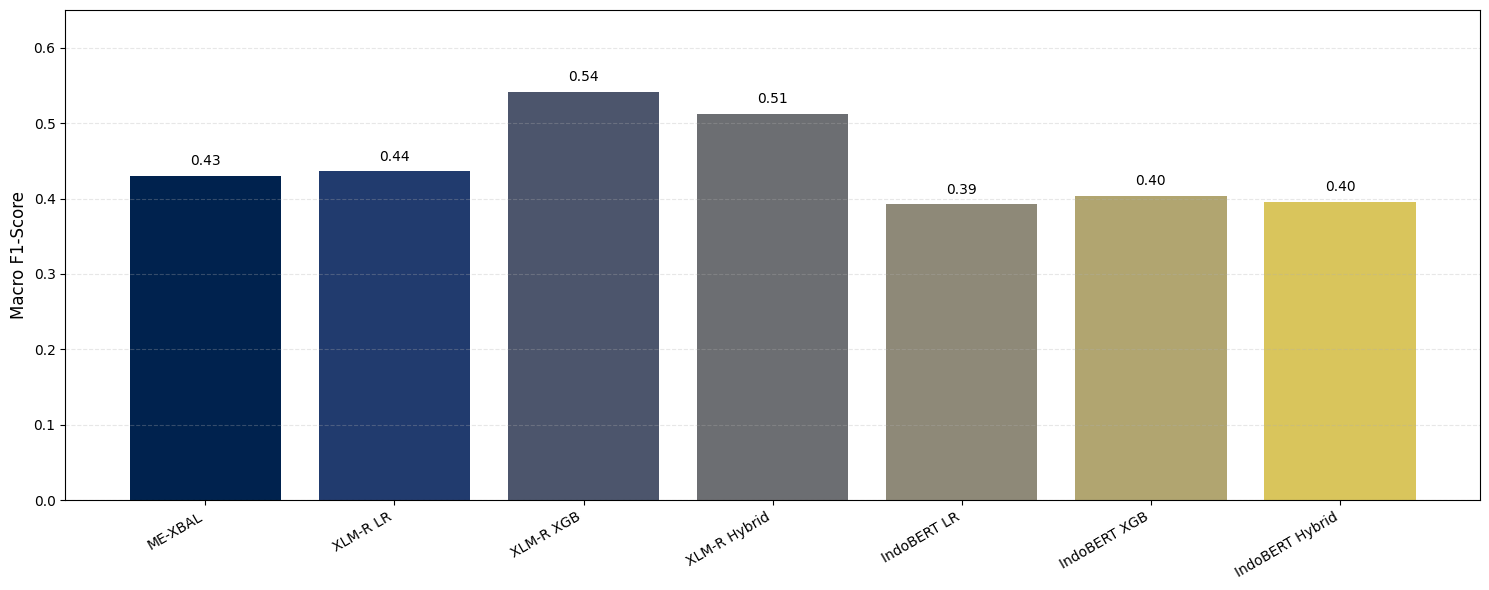

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# ================================
# DATA
# ================================
models = [
    "ME-XBAL",
    "XLM-R LR",
    "XLM-R XGB",
    "XLM-R Hybrid",
    "IndoBERT LR",
    "IndoBERT XGB",
    "IndoBERT Hybrid"
]

scores = [
    0.4300,
    0.4360,
    0.5415,
    0.5125,
    0.3923,
    0.4040,
    0.3959
]

# ================================
# SETUP
# ================================
x = np.arange(len(models))

plt.figure(figsize=(15, 6))

# ================================
# CIVIDIS COLOR MAP
# ================================
cmap = plt.cm.cividis
colors = [cmap(i / len(models)) for i in range(len(models))]

# ================================
# BAR PLOT
# ================================
bars = plt.bar(x, scores, color=colors)

# ================================
# LABEL & TITLE
# ================================
plt.ylabel('Macro F1-Score', fontsize=12)
# plt.title('Ablation Study on Indo-Sundanese Dataset (Single-Label)', fontsize=14, fontweight='bold')
plt.xticks(x, models, rotation=30, ha='right')

# ================================
# VALUE LABELS
# ================================
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.01,
        f'{height:.2f}',
        ha='center',
        va='bottom',
        fontsize=10
    )

# ================================
# GRID
# ================================
plt.grid(axis='y', linestyle='--', alpha=0.3)

# ================================
# LIMIT
# ================================
plt.ylim(0, 0.65)

plt.tight_layout()
plt.show()